In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
import matplotlib.pyplot as plt 

In [16]:
data_path = r'C:\Users\User\OneDrive\Desktop\AIML\outputs\outputs'

In [17]:
categories = os.listdir(data_path)
print(categories)

['Disappointed', 'Interested', 'Neutral']


In [18]:
# --- Define the Parameters ---

In [19]:
img_height = 40
img_width = 40

img_size = (img_height, img_width)
b_size = 64

In [20]:
print("Loading training data....")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123, # Using a seed ensures the split is reproducible
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading training data....
Found 34395 files belonging to 3 classes.
Using 27516 files for training.


In [21]:
print("Loading validation data...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123, # Using a seed ensures the split is reproducible
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading validation data...
Found 34395 files belonging to 3 classes.
Using 6879 files for validation.


In [22]:
class_names = train_dataset.class_names
print(f"Found class names: {class_names}")

Found class names: ['Disappointed', 'Interested', 'Neutral']


In [23]:
# Optimize performance by caching and prefetching the data
autotune = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size = autotune)
validation_dataset = validation_dataset.cache().prefetch(buffer_size = autotune)

In [24]:
model = Sequential([
    Input(shape=(img_height, img_width, 1)),
    
    Rescaling(1./255), 
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.3),
    
    Dense(3, activation='softmax')
])

In [25]:
# --- COMPILE THE MODEL ---

In [26]:
model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 40, 40, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 40, 40, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 40, 40, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 20, 20, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 20, 20, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 20, 20, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 10, 10, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 10, 10, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 503,683 (1.92 MB)

 Trainable params: 503,235 (1.92 MB)

 Non-trainable params: 448 (1.75 KB)

In [28]:
# --- TRAIN THE MODEL ---

In [30]:
print("\nStarting model training....")

history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 20
)

print("\nTraining complete...")


Starting model training....
Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.4606 - loss: 0.9796 - val_accuracy: 0.5132 - val_loss: 0.9653
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 34s 79ms/step - accuracy: 0.5045 - loss: 0.9385 - val_accuracy: 0.5597 - val_loss: 0.8747
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 81ms/step - accuracy: 0.5307 - loss: 0.9151 - val_accuracy: 0.5691 - val_loss: 0.8721
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 34s 80ms/step - accuracy: 0.5673 - loss: 0.8764 - val_accuracy: 0.5649 - val_loss: 0.8615
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.5871 - loss: 0.8421 - val_accuracy: 0.5636 - val_loss: 0.8945
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 81ms/step - accuracy: 0.6024 - loss: 0.8043 - val_accuracy: 0.6245 - val_loss: 0.8165
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.6209 - loss: 0.7650 - val_accuracy: 0.5933 - val_loss: 0.8276
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 81ms/step - accur

In [31]:
# --- EVALUATE AND VISUALIZE THE RESULTS ---


Evaluating model on validation data....
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6190 - loss: 1.3319
Final Validation Accuracy: 61.90%


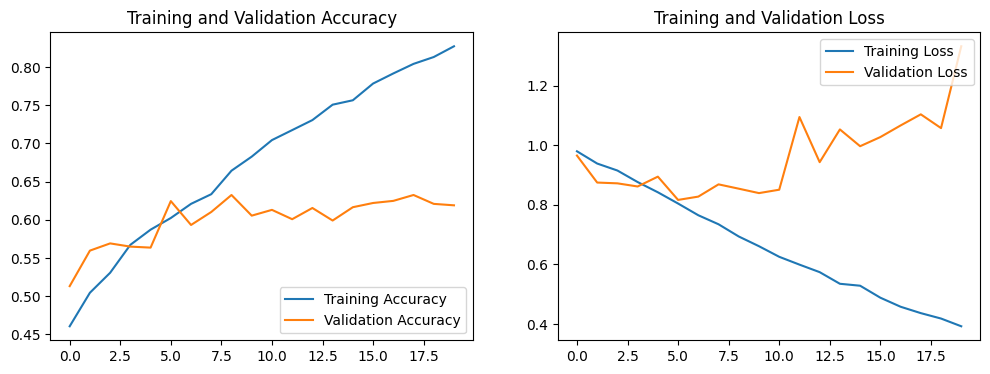

In [32]:
print("\nEvaluating model on validation data....")
loss, accuracy = model.evaluate(validation_dataset)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")


# Plot the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(20)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ------------ The Classification Report ------------

In [ ]:
print("Gathering predictions from validation set...")
y_pred = [] 
y_true = []

for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("Predictions gathered...")

print("Classification Report")
print("---" * 10)

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# ------------ The Confusion Matrix ------------

In [ ]:
print("Generating Confusion Matrix...")
print("---" * 10)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()